In [1]:
# for interactive plots:
# %matplotlib widget

# for static plots:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt

# Optics calculation and matching

For more info, see [Twiss](https://xsuite.readthedocs.io/en/latest/twiss.html) and [Match](https://xsuite.readthedocs.io/en/latest/match.html) sections in the User's Guide.

In [3]:
import xtrack as xt

### Load model

In [4]:
env = xt.load('./pimm.json')
ring = env['ring']

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

In [5]:
ring.set_particle_ref('proton', kinetic_energy0=100e6)

### Inspect quadrupole circuits

In [6]:
env.info('kqfa')

Info for vars['kqfa']

value: 0.0

Not controlled by other entities.

controlled_targets:
   element_refs['qfal.3'].k1
   element_refs['qfal.2'].k1
   element_refs['qfal.1'].k1
   element_refs['qfal.0'].k1
   element_refs['qfar.3'].k1
   element_refs['qfar.2'].k1
   element_refs['qfar.1'].k1
   element_refs['qfar.0'].k1
   element_refs['qfar'].k1
   element_refs['qfal'].k1
   element_refs['qfa'].k1



In [7]:
env.info('kqfb')

Info for vars['kqfb']

value: 0.0

Not controlled by other entities.

controlled_targets:
   element_refs['qfb.7'].k1
   element_refs['qfb.6'].k1
   element_refs['qfb.5'].k1
   element_refs['qfb.4'].k1
   element_refs['qfb.3'].k1
   element_refs['qfb.2'].k1
   element_refs['qfb.1'].k1
   element_refs['qfb.0'].k1
   element_refs['qfb'].k1



### Set some initial strengths to get a first twiss

In [8]:
env['kqfa'] =  0.01
env['kqfb'] =  0.01
env['kqd']  = -0.02

In [9]:
# Compute twiss parameters
tw = ring.twiss4d(chrom=False)

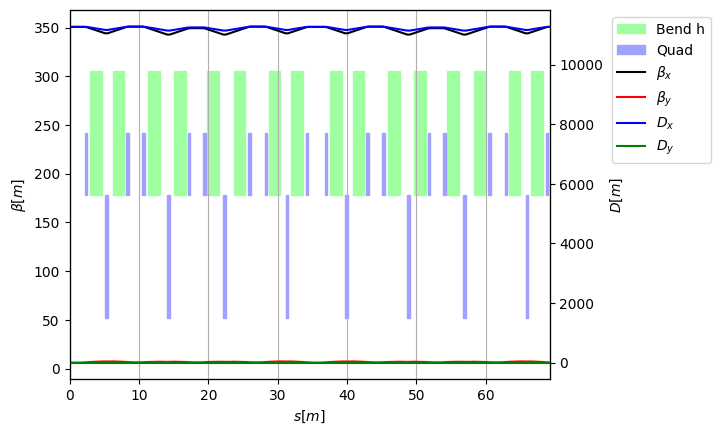

In [10]:
# Plot twiss parameters
tw.plot()

### Match the tunes

In [11]:
opt_tune = ring.match(
    solve=False, # <- prepare the match without running it
    chrom=False,
    method='4d',
    vary=[
        xt.Vary('kqfa', limits=(0, 10),  step=1e-3),
        xt.Vary('kqfb', limits=(0, 10),  step=1e-3),
        xt.Vary('kqd', limits=(-10, 0), step=1e-3),
    ],
    targets=[
        xt.TargetSet(qx=1.64, qy=1.72, tol=1e-6),
    ]
)

In [12]:
opt_tune.target_status()

Target status:               alty = 1.6107e+01              
id state tag tol_met       residue   current_val    target_val description                         
0  ON    qx    False      -1.60864     0.0313631          1.64 'qx', val=1.64, tol=1e-06, weight=10
1  ON    qy    False    -0.0807693       1.63923          1.72 'qy', val=1.72, tol=1e-06, weight=10


In [13]:
opt_tune.run_jacobian(30)

                                             
Optimize - start penalty: 16.11                             
Matching: model call n. 32 penalty = 1.3669e-08              
Optimize - end penalty:  1.36687e-08                            


In [14]:
opt_tune.target_status()

Target status:               nalty = 1.3669e-08              
id state tag tol_met       residue   current_val    target_val description                         
0  ON    qx     True  -1.36671e-09          1.64          1.64 'qx', val=1.64, tol=1e-06, weight=10
1  ON    qy     True   -2.1114e-11          1.72          1.72 'qy', val=1.72, tol=1e-06, weight=10


In [15]:
opt_tune.vary_status()

Vary status:                 
id state tag met name lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqfa           0      0.435867          10          0.01         0.001             1
1  ON        OK  kqfb           0      0.440097          10          0.01         0.001             1
2  ON        OK  kqd          -10     -0.585124           0         -0.02         0.001             1


### Inspect the optics

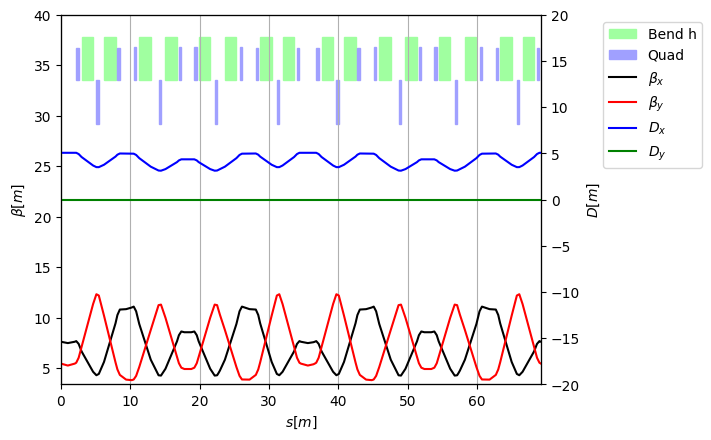

In [16]:
# Twiss and plot again
tw = ring.twiss4d()
pl = tw.plot()
pl.ylim(left_hi=40, right_lo=-20, right_hi=20,
        lattice_hi=1.5, lattice_lo=-7)

### Add constraint on dispersion at the center of the long straight sections

In [17]:
opt_disp = opt_tune.clone(
    add_targets=[
        xt.TargetSet(dx=0, at='mid.lss.0', tol=1e-3),
        xt.TargetSet(dx=0, at='mid.lss.1', tol=1e-3),
    ])

In [18]:
opt_disp.target_status()

Target status:               alty = 7.1697e+01              
id state tag          tol_met       residue   current_val    target_val description                                 
0  ON    qx              True  -1.36671e-09          1.64          1.64 'qx', val=1.64, tol=1e-06, weight=10        
1  ON    qy              True   -2.1114e-11          1.72          1.72 'qy', val=1.72, tol=1e-06, weight=10        
2  ON    mid.lss.0_dx   False       5.06976       5.06976             0 ('dx', 'mid.lss.0'), val=0, tol=0.001, w ...
3  ON    mid.lss.1_dx   False       5.06976       5.06976             0 ('dx', 'mid.lss.1'), val=0, tol=0.001, w ...


In [19]:
opt_disp.run_simplex(100)

                                             
Optimize - start penalty: 71.7                              
Matching: model call n. 185 penalty = 6.5467e-05              
Optimize - end penalty:  6.54674e-05                            


### Inspect the optics

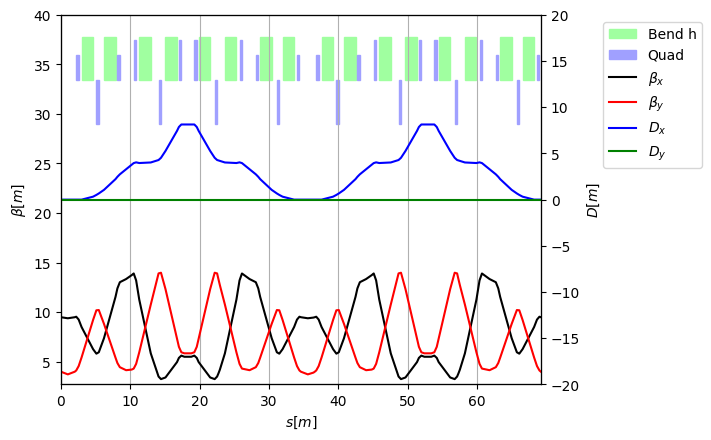

In [20]:
tw = ring.twiss4d()
pl = tw.plot()
pl.ylim(left_hi=40, right_lo=-20, right_hi=20,
        lattice_hi=1.5, lattice_lo=-7)

## Correct chromaticity

In [21]:
opt_chrom = ring.match(
    solve=False,
    method='4d',
    vary=xt.VaryList(['ksf', 'ksd'], step=1e-3),
    targets=xt.TargetSet(dqx=-0.01, dqy=-0.01, tol=1e-3))

In [22]:
opt_chrom.target_status()

Target status:               alty = 1.2017e+00              
id state tag tol_met       residue   current_val    target_val description                          
0  ON    dqx   False     -0.561943     -0.571943         -0.01 'dqx', val=-0.01, tol=0.001, weight=1
1  ON    dqy   False      -1.06223      -1.07223         -0.01 'dqy', val=-0.01, tol=0.001, weight=1


In [23]:
opt_chrom.run_ls_dogbox(30)

Matching: model call n. 49 penalty = 1.4805e-08              

In [24]:
opt_chrom.target_status()

Target status:               nalty = 1.4805e-08              
id state tag tol_met       residue   current_val    target_val description                          
0  ON    dqx    True   9.17799e-10         -0.01         -0.01 'dqx', val=-0.01, tol=0.001, weight=1
1  ON    dqy    True  -1.47763e-08         -0.01         -0.01 'dqy', val=-0.01, tol=0.001, weight=1


## Save strengths to file

In [25]:
quad_strengths = opt_disp.get_knob_values()
quad_strengths

{'kqfa': np.float64(0.33773306392384533),
 'kqfb': np.float64(0.54694196901415),
 'kqd': np.float64(-0.5904781381850552)}

In [26]:
sext_strengths = opt_chrom.get_knob_values()
sext_strengths

{'ksf': np.float64(0.5835019945466369), 'ksd': np.float64(-0.7807717418886633)}

In [27]:
# Merge the two dictionaries
strengths = quad_strengths | sext_strengths
strengths

{'kqfa': np.float64(0.33773306392384533),
 'kqfb': np.float64(0.54694196901415),
 'kqd': np.float64(-0.5904781381850552),
 'ksf': np.float64(0.5835019945466369),
 'ksd': np.float64(-0.7807717418886633)}

In [28]:
xt.json.dump(strengths, 'pimm_strengths.json')